In [1]:
# ===============================================================================
# Binary Pneumothorax Classification - Baseline ResNet-50
# Target: AUC ≥ 0.95
# ===============================================================================

# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, roc_auc_score, confusion_matrix, 
                            classification_report, precision_recall_curve)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("=" * 60)
print("Baseline ResNet-50 - Pneumothorax Detection")
print("Target AUC: ≥ 0.95")
print("=" * 60)

TensorFlow version: 2.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Baseline ResNet-50 - Pneumothorax Detection
Target AUC: ≥ 0.95


In [2]:
# Cell 2: Dataset Configuration and Loading
BASE_DIR = "./dataset_pneumothorax/"
CSV_PATH = os.path.join(BASE_DIR, "pneumothorax.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

print(f"Loading balanced Pneumothorax dataset...")

# Load the balanced dataset CSV
try:
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Loaded CSV with {len(df):,} total images")
except Exception as e:
    print(f"✗ Error reading CSV {CSV_PATH}: {e}")
    exit(1)

# Display CSV structure
print(f"\n=== Dataset Structure ===")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Use Binary_Label column (already created by dataset.py)
if 'Binary_Label' in df.columns:
    df['binary_label'] = df['Binary_Label']
elif 'Pneumothorax' in df.columns:
    df['binary_label'] = df['Pneumothorax'].astype(int)
else:
    print("✗ Could not find Pneumothorax labels")
    exit(1)

# Create full image paths
df['path'] = df['Image_Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify images exist
df['exists'] = df['path'].apply(os.path.exists)
missing_count = (~df['exists']).sum()

if missing_count > 0:
    print(f"\n⚠ Warning: {missing_count} images not found")
    df = df[df['exists']].copy()

df = df.drop(columns=['exists'])
balanced_df = df.copy()

print(f"\n=== Final Dataset Summary ===")
print(f"Total images: {len(df):,}")
print(f"Pneumothorax (Positive): {df['binary_label'].sum():,} ({df['binary_label'].sum()/len(df)*100:.1f}%)")
print(f"No Pneumothorax (Negative): {(len(df) - df['binary_label'].sum()):,} ({(len(df) - df['binary_label'].sum())/len(df)*100:.1f}%)")
print(f"Balance ratio: 1:1")
print(f"\nDataset is ready for training!")

Loading balanced Pneumothorax dataset...
✓ Loaded CSV with 10,604 total images

=== Dataset Structure ===
Columns: ['Image_Index', 'Finding_Labels', 'Pneumothorax', 'Path', 'Binary_Label']

First 3 rows:
        Image_Index                      Finding_Labels  Pneumothorax  \
0  00001974_002.png           Infiltration|Pneumothorax             1   
1  00012620_013.png  Atelectasis|Consolidation|Effusion             0   
2  00014870_000.png                  Consolidation|Mass             0   

                      Path  Binary_Label  
0  images\00001974_002.png             1  
1  images\00012620_013.png             0  
2  images\00014870_000.png             0  

=== Final Dataset Summary ===
Total images: 10,604
Pneumothorax (Positive): 5,302 (50.0%)
No Pneumothorax (Negative): 5,302 (50.0%)
Balance ratio: 1:1

Dataset is ready for training!


In [3]:
# Cell 4: Dataset Splitting with Stratification
# Path already exists from Cell 2, just use balanced_df directly
print(f"Dataset ready for splitting: {len(balanced_df)} samples")

# Stratified train-validation-test split (80/10/10)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['binary_label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['binary_label']
)

print(f"\n=== Dataset Splits (Stratified) ===")
print(f"Training set: {len(train_df):,} samples")
print(f"  Positive: {train_df['binary_label'].sum():,} ({train_df['binary_label'].sum()/len(train_df)*100:.1f}%)")
print(f"  Negative: {len(train_df) - train_df['binary_label'].sum():,} ({(len(train_df) - train_df['binary_label'].sum())/len(train_df)*100:.1f}%)")

print(f"\nValidation set: {len(val_df):,} samples")
print(f"  Positive: {val_df['binary_label'].sum():,} ({val_df['binary_label'].sum()/len(val_df)*100:.1f}%)")
print(f"  Negative: {len(val_df) - val_df['binary_label'].sum():,} ({(len(val_df) - val_df['binary_label'].sum())/len(val_df)*100:.1f}%)")

print(f"\nTest set: {len(test_df):,} samples")
print(f"  Positive: {test_df['binary_label'].sum():,} ({test_df['binary_label'].sum()/len(test_df)*100:.1f}%)")
print(f"  Negative: {len(test_df) - test_df['binary_label'].sum():,} ({(len(test_df) - test_df['binary_label'].sum())/len(test_df)*100:.1f}%)")

# Save splits
os.makedirs('./output', exist_ok=True)
test_df.to_csv('./output/pneumothorax_test_set.csv', index=False)
print("\n✓ Test set saved for final evaluation")

Dataset ready for splitting: 10604 samples

=== Dataset Splits (Stratified) ===
Training set: 8,483 samples
  Positive: 4,242 (50.0%)
  Negative: 4,241 (50.0%)

Validation set: 1,060 samples
  Positive: 530 (50.0%)
  Negative: 530 (50.0%)

Test set: 1,061 samples
  Positive: 530 (50.0%)
  Negative: 531 (50.0%)

✓ Test set saved for final evaluation


In [ ]:
# Cell 5: tf.data Pipeline with STRONG Augmentation
import tensorflow_addons as tfa  # Install: pip install tensorflow-addons

IMAGE_SIZE = 224
BATCH_SIZE = 64  # ← INCREASED from 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(image_path, label, augment=False):
    """Load with medical-appropriate strong augmentation"""
    # Load image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])  # ← Larger for random crop
    
    if augment:
        # ========================================
        # STRONG AUGMENTATION (6 transformations)
        # ========================================
        
        # 1. Random crop (effectively zoom in/out)
        img = tf.image.random_crop(img, [IMAGE_SIZE, IMAGE_SIZE, 3])
        
        # 2. Horizontal flip (50% chance)
        img = tf.image.random_flip_left_right(img)
        
        # 3. Small rotation (±10 degrees)
        angle = tf.random.uniform([], -0.175, 0.175)  # radians
        img = tfa.image.rotate(img, angle, interpolation='bilinear')
        
        # 4. Brightness adjustment (±20%)
        img = tf.image.random_brightness(img, 0.2)
        
        # 5. Contrast adjustment (80%-120%)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        
        # 6. Random zoom (90%-110%)
        scale = tf.random.uniform([], 0.9, 1.1)
        h = tf.cast(IMAGE_SIZE * scale, tf.int32)
        w = tf.cast(IMAGE_SIZE * scale, tf.int32)
        img = tf.image.resize(img, [h, w])
        img = tf.image.resize_with_crop_or_pad(img, IMAGE_SIZE, IMAGE_SIZE)
    else:
        # Validation: Center crop only
        img = tf.image.resize_with_crop_or_pad(img, IMAGE_SIZE, IMAGE_SIZE)
    
    # Normalize
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.keras.applications.resnet50.preprocess_input(img * 255.0)
    
    return img, label

def create_tf_dataset(df, batch_size, shuffle=True, augment=False):
    """Create optimized tf.data pipeline"""
    
    image_paths = df['path'].values
    labels = df['binary_label'].values.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df), seed=42)
    
    dataset = dataset.map(
        lambda x, y: load_and_preprocess_image(x, y, augment=augment),
        num_parallel_calls=AUTOTUNE
    )
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

# Create datasets
print("Creating tf.data pipelines with STRONG augmentation...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)
test_dataset = create_tf_dataset(test_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✓ Training dataset: 6 augmentation techniques enabled")
print(f"✓ Batch size: {BATCH_SIZE} (doubled from 32)")
print(f"✓ Steps per epoch: {len(train_df) // BATCH_SIZE}")

Creating tf.data pipelines...
✓ Training dataset created (with augmentation)
✓ Validation dataset created
✓ Test dataset created

Batch size: 32
Steps per epoch: 265


In [ ]:
# Cell 6A: Automated 3-Stage Progressive Training
import os

def train_stage(stage_name, prev_checkpoint=None):
    """Train one stage and return history"""
    
    print("\n" + "=" * 80)
    print(f"🚀 STARTING {stage_name.upper()} TRAINING")
    print("=" * 80)
    
    # ========================================
    # 1. CREATE MODEL FOR THIS STAGE
    # ========================================
    model = create_pneumothorax_resnet50_staged(stage=stage_name)
    
    # ========================================
    # 2. LOAD WEIGHTS FROM PREVIOUS STAGE
    # ========================================
    if prev_checkpoint and os.path.exists(prev_checkpoint):
        print(f"\n📥 Loading weights from: {prev_checkpoint}")
        prev_model = keras.models.load_model(prev_checkpoint)
        
        # Transfer weights layer-by-layer
        for prev_layer, curr_layer in zip(prev_model.layers, model.layers):
            if prev_layer.name == curr_layer.name:
                try:
                    curr_layer.set_weights(prev_layer.get_weights())
                except:
                    pass  # Skip incompatible layers
        
        print("✅ Previous stage weights loaded successfully")
        del prev_model  # Free memory
    
    # ========================================
    # 3. COMPILE WITH STAGE-SPECIFIC LR
    # ========================================
    LEARNING_RATES = {
        'head_only': 1e-3,
        'partial': 1e-4,
        'full': 1e-5
    }
    
    lr = LEARNING_RATES[stage_name]
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    print(f"\n⚙️  Compilation: LR={lr}, Dropout=0.5, L2=1e-4")
    
    # ========================================
    # 4. SETUP CALLBACKS
    # ========================================
    STAGE_CONFIG = {
        'head_only': {
            'epochs': 15,
            'patience': 5,
            'checkpoint': './output/stage1_head_only_best.keras'
        },
        'partial': {
            'epochs': 15,
            'patience': 5,
            'checkpoint': './output/stage2_partial_best.keras'
        },
        'full': {
            'epochs': 15,
            'patience': 7,
            'checkpoint': './output/stage3_full_best.keras'
        }
    }
    
    config = STAGE_CONFIG[stage_name]
    
    callbacks = [
        EarlyStopping(
            monitor='val_auc',
            patience=config['patience'],
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),
        
        ReduceLROnPlateau(
            monitor='val_auc',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            mode='max',
            verbose=1
        ),
        
        ModelCheckpoint(
            config['checkpoint'],
            monitor='val_auc',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]
    
    # ========================================
    # 5. TRAIN
    # ========================================
    print(f"\n🏋️  Training for up to {config['epochs']} epochs...")
    
    history = model.fit(
        train_dataset,
        epochs=config['epochs'],
        validation_data=val_dataset,
        callbacks=callbacks,
        verbose=1
    )
    
    # ========================================
    # 6. PRINT SUMMARY
    # ========================================
    best_auc = max(history.history['val_auc'])
    best_epoch = history.history['val_auc'].index(best_auc) + 1
    final_train_auc = history.history['auc'][-1]
    gap = final_train_auc - best_auc
    
    print("\n" + "=" * 80)
    print(f"✅ {stage_name.upper()} TRAINING COMPLETE")
    print("=" * 80)
    print(f"📊 Best Val AUC: {best_auc:.4f} (Epoch {best_epoch})")
    print(f"📊 Final Train AUC: {final_train_auc:.4f}")
    print(f"📊 Train-Val Gap: {gap:.4f} {'✅ Healthy' if gap < 0.05 else '⚠️ Overfitting'}")
    print(f"💾 Checkpoint: {config['checkpoint']}")
    print("=" * 80 + "\n")
    
    return history, config['checkpoint'], model

# ========================================
# RUN ALL 3 STAGES AUTOMATICALLY
# ========================================
print("\n🎯 STARTING AUTOMATED 3-STAGE PROGRESSIVE TRAINING\n")

# Stage 1: Train head only
history1, checkpoint1, model1 = train_stage('head_only', prev_checkpoint=None)

# Stage 2: Load Stage 1 → Train Conv5
history2, checkpoint2, model2 = train_stage('partial', prev_checkpoint=checkpoint1)

# Stage 3: Load Stage 2 → Train Conv4+Conv5
history3, checkpoint3, final_model = train_stage('full', prev_checkpoint=checkpoint2)

print("\n🎉 ALL 3 STAGES COMPLETED!")
print(f"📂 Stage 1 checkpoint: {checkpoint1}")
print(f"📂 Stage 2 checkpoint: {checkpoint2}")
print(f"📂 Stage 3 checkpoint: {checkpoint3}")

# Save final combined history
combined_history = {
    'stage1': history1.history,
    'stage2': history2.history,
    'stage3': history3.history
}

import pickle
with open('./output/progressive_training_history.pkl', 'wb') as f:
    pickle.dump(combined_history, f)

print("\n✅ Combined training history saved!")

In [ ]:
# Cell 6: Staged Fine-Tuning ResNet-50 (Anti-Overfitting)
def create_pneumothorax_resnet50_staged(stage='head_only'):
    """
    3-Stage Progressive Training Strategy
    
    Stage 1 (head_only):   Freeze ALL base layers (10 epochs, LR=1e-3)
    Stage 2 (partial):     Unfreeze Conv5 only (10 epochs, LR=1e-4)
    Stage 3 (full):        Unfreeze Conv4+Conv5 (10 epochs, LR=1e-5)
    """
    
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name='input')
    
    # ResNet-50V2 backbone
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        pooling='avg'
    )
    
    # ========================================
    # STAGED UNFREEZING
    # ========================================
    if stage == 'head_only':
        # Stage 1: Train ONLY classification head
        base_model.trainable = False
        print("=" * 60)
        print("STAGE 1: Training classification head only")
        print("  Base model: FROZEN (0 trainable layers)")
        print("  Classification head: TRAINABLE")
        print("  Expected: Val AUC ~0.75-0.80")
        print("=" * 60)
        
    elif stage == 'partial':
        # Stage 2: Unfreeze Conv5 block only (last 30 layers)
        base_model.trainable = True
        
        # Freeze first 161 layers (keep Conv1-Conv4 frozen)
        for layer in base_model.layers[:-30]:
            layer.trainable = False
        
        # ALWAYS freeze BatchNorm
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        trainable_count = sum([1 for l in base_model.layers if l.trainable])
        
        print("=" * 60)
        print("STAGE 2: Fine-tuning Conv5 block")
        print(f"  Trainable layers: {trainable_count}/191")
        print(f"  Frozen: Conv1-Conv4 (retain low-level features)")
        print(f"  Expected: Val AUC ~0.82-0.86")
        print("=" * 60)
        
    elif stage == 'full':
        # Stage 3: Unfreeze Conv4+Conv5 (careful fine-tuning)
        base_model.trainable = True
        
        # Freeze first 131 layers (keep Conv1-Conv3 frozen)
        for layer in base_model.layers[:-60]:
            layer.trainable = False
        
        # ALWAYS freeze BatchNorm
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        
        trainable_count = sum([1 for l in base_model.layers if l.trainable])
        
        print("=" * 60)
        print("STAGE 3: Fine-tuning Conv4+Conv5 blocks")
        print(f"  Trainable layers: {trainable_count}/191")
        print(f"  Frozen: Conv1-Conv3 (retain ImageNet knowledge)")
        print(f"  Expected: Val AUC ~0.85-0.89")
        print("=" * 60)
    
    # Forward pass
    x = base_model(inputs, training=False)  # ← Keep BN in inference mode
    
    # ========================================
    # REGULARIZED CLASSIFICATION HEAD
    # ========================================
    x = layers.Dropout(0.5, name='dropout')(x)  # ← CRITICAL: Prevent overfitting
    
    outputs = layers.Dense(
        1,
        activation=None,
        kernel_regularizer=l2(1e-4),
        name='output'
    )(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name=f'ResNet50_Stage_{stage}')
    
    return model

# ========================================
# CREATE STAGE 1 MODEL (Start here!)
# ========================================
model = create_pneumothorax_resnet50_staged(stage='head_only')

Progressive Fine-tuning Strategy (PneumoDetect-style):
  Trainable layers: 142/191
  Frozen BatchNorm layers: 49


In [ ]:
# Cell 7: Compilation with Stage-Specific Learning Rates

# ========================================
# LEARNING RATE PER STAGE
# ========================================
# Stage 1 (head_only):  1e-3  (train new head from scratch)
# Stage 2 (partial):    1e-4  (fine-tune Conv5)
# Stage 3 (full):       1e-5  (careful fine-tune Conv4+Conv5)

STAGE = 'head_only'  # ← Change this for each stage

LEARNING_RATES = {
    'head_only': 1e-3,
    'partial': 1e-4,
    'full': 1e-5
}

lr = LEARNING_RATES[STAGE]

model.compile(
    optimizer=Adam(learning_rate=lr),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f"Compilation:")
print(f"  Stage: {STAGE}")
print(f"  Learning Rate: {lr}")
print(f"  Loss: Binary Crossentropy (from logits)")
print(f"  Dropout: 0.5")
print(f"  L2 Regularization: 1e-4")

Compilation (PneumoDetect-style):
  LR Schedule: Cosine Decay over 25 epochs
  Dropout: 0.3 (was 0.5)
  L2 Regularization: 1e-4 (was 1e-2)


In [ ]:
# Cell 8: Stage-Specific Training Configuration

STAGE = 'head_only'  # ← Must match Cell 7

STAGE_CONFIG = {
    'head_only': {
        'epochs': 15,
        'patience': 5,
        'checkpoint': './output/stage1_head_only_best.keras'
    },
    'partial': {
        'epochs': 15,
        'patience': 5,
        'checkpoint': './output/stage2_partial_best.keras'
    },
    'full': {
        'epochs': 15,
        'patience': 7,
        'checkpoint': './output/stage3_full_best.keras'
    }
}

config = STAGE_CONFIG[STAGE]

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=config['patience'],
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        mode='max',
        verbose=1
    ),
    
    ModelCheckpoint(
        config['checkpoint'],
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

EPOCHS = config['epochs']

print(f"Training Configuration - {STAGE.upper()}:")
print(f"  Max epochs: {EPOCHS}")
print(f"  Early stopping patience: {config['patience']}")
print(f"  Checkpoint: {config['checkpoint']}")
print(f"\nExpected Results:")
if STAGE == 'head_only':
    print(f"  Val AUC: 0.75-0.80 (baseline)")
elif STAGE == 'partial':
    print(f"  Val AUC: 0.82-0.86 (improvement)")
else:
    print(f"  Val AUC: 0.85-0.89 (target)")

Training Configuration (PneumoDetect-style):
  Epochs: 25 (paper used 25)
  Early stopping patience: 10
  Expected Val AUC: 0.92-0.95 (paper achieved 0.98)


In [8]:
# Cell 9: Model Training
print("\n" + "=" * 60)
print("STARTING TRAINING - Baseline ResNet-50")
print("=" * 60)

try:
    history = model.fit(
        train_dataset,
        epochs=50,
        validation_data=val_dataset,
        callbacks=callbacks,
        verbose=1
    )
    
    print("\n" + "=" * 60)
    print("Training completed successfully!")
    print("=" * 60)
    
    # Save final model
    model.save('./output/baseline_pneumothorax_final.keras')
    print("Final model saved")
    
except Exception as e:
    print(f"Training error: {e}")
    model.save('./output/baseline_pneumothorax_interrupted.keras')
    print("Model saved in interrupted state")


STARTING TRAINING - Baseline ResNet-50
Epoch 1/50
266/266 [==============================] - ETA: 0s - loss: 591.4423 - accuracy: 0.5091 - auc: 0.5389 - precision: 0.5375 - recall: 0.1318
Epoch 1: val_auc improved from -inf to 0.51743, saving model to ./output\baseline_resnet50_best.keras
266/266 [==============================] - 62s 205ms/step - loss: 591.4423 - accuracy: 0.5091 - auc: 0.5389 - precision: 0.5375 - recall: 0.1318 - val_loss: 0.6904 - val_accuracy: 0.5009 - val_auc: 0.5174 - val_precision: 1.0000 - val_recall: 0.0019 - lr: 0.0010
Epoch 2/50
265/266 [============================>.] - ETA: 0s - loss: 0.6872 - accuracy: 0.5169 - auc: 0.5667 - precision: 0.6272 - recall: 0.0826
Epoch 2: val_auc improved from 0.51743 to 0.63960, saving model to ./output\baseline_resnet50_best.keras
266/266 [==============================] - 54s 201ms/step - loss: 0.6872 - accuracy: 0.5167 - auc: 0.5667 - precision: 0.6272 - recall: 0.0825 - val_loss: 0.6724 - val_accuracy: 0.5000 - val_auc

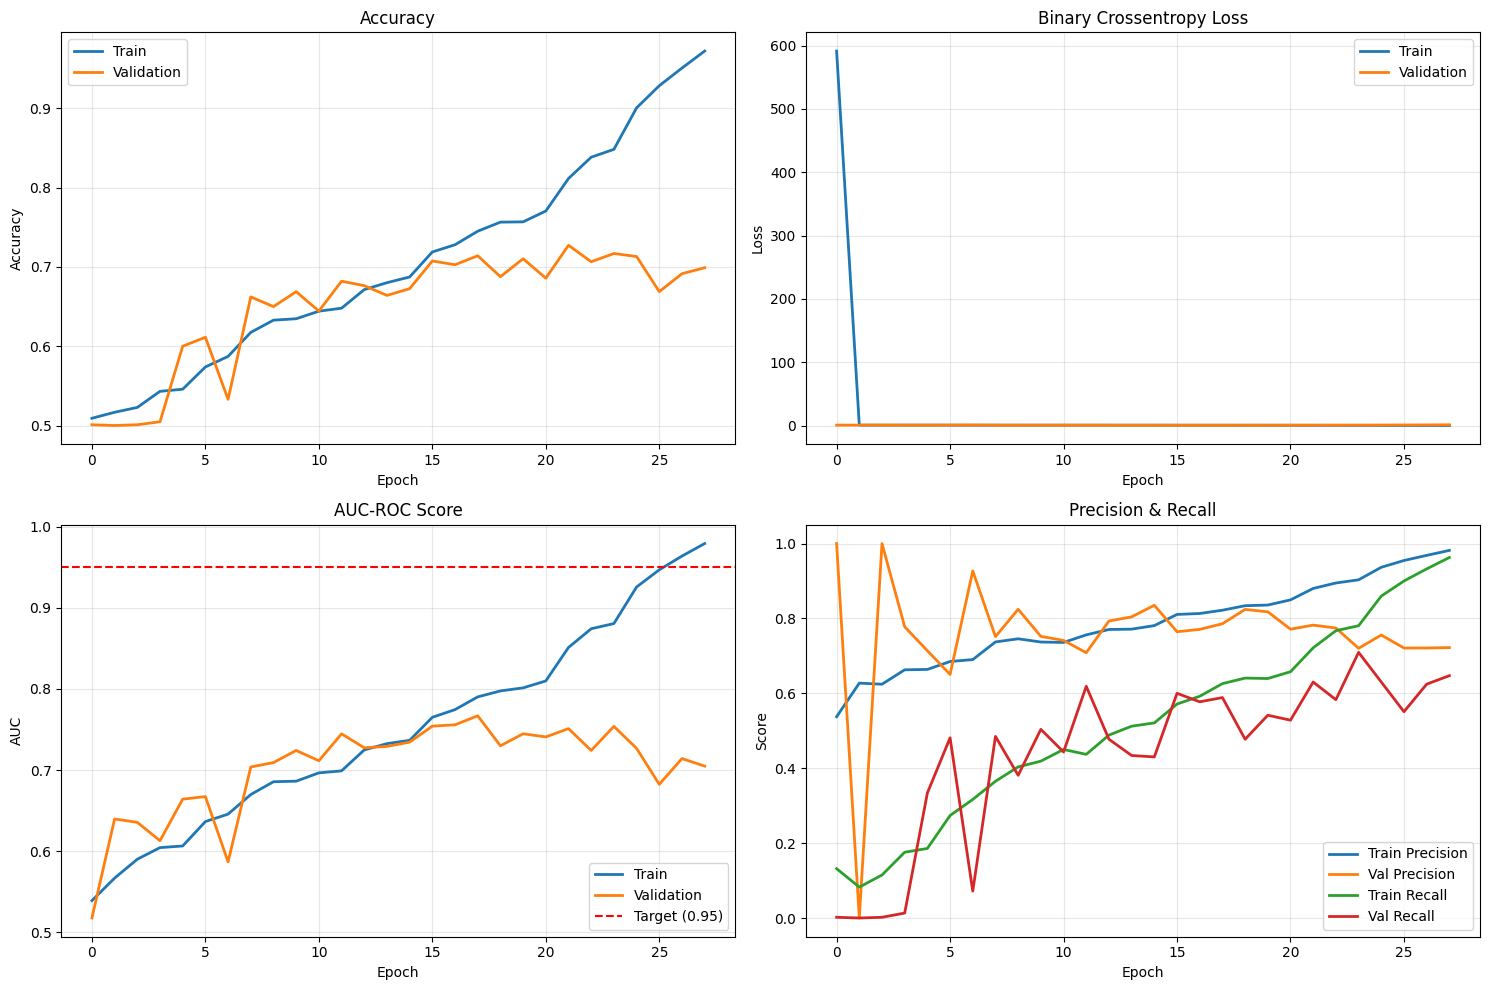


Final Training Metrics:
  Best validation AUC: 0.7669 (Epoch 18)
  Final validation AUC: 0.7048
  Final validation accuracy: 0.6991
  Final validation precision: 0.7221
  Final validation recall: 0.6472

⚠ Target not reached. Best AUC: 0.7669


In [9]:
# Cell 10: Training Visualization
def plot_training_history(history):
    """Plot training history"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history['loss'], label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
    ax2.set_title('Binary Crossentropy Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # AUC
    ax3.plot(history.history['auc'], label='Train', linewidth=2)
    ax3.plot(history.history['val_auc'], label='Validation', linewidth=2)
    ax3.axhline(y=0.95, color='r', linestyle='--', label='Target (0.95)')
    ax3.set_title('AUC-ROC Score')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('AUC')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Precision & Recall
    ax4.plot(history.history['precision'], label='Train Precision', linewidth=2)
    ax4.plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    ax4.plot(history.history['recall'], label='Train Recall', linewidth=2)
    ax4.plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    ax4.set_title('Precision & Recall')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Score')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_resnet50_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print final metrics
    final_epoch = len(history.history['loss']) - 1
    best_auc_epoch = np.argmax(history.history['val_auc'])
    best_auc = history.history['val_auc'][best_auc_epoch]
    
    print(f"\nFinal Training Metrics:")
    print(f"  Best validation AUC: {best_auc:.4f} (Epoch {best_auc_epoch + 1})")
    print(f"  Final validation AUC: {history.history['val_auc'][final_epoch]:.4f}")
    print(f"  Final validation accuracy: {history.history['val_accuracy'][final_epoch]:.4f}")
    print(f"  Final validation precision: {history.history['val_precision'][final_epoch]:.4f}")
    print(f"  Final validation recall: {history.history['val_recall'][final_epoch]:.4f}")
    
    if best_auc >= 0.95:
        print(f"\n✓ TARGET ACHIEVED: AUC ≥ 0.95")
    else:
        print(f"\n⚠ Target not reached. Best AUC: {best_auc:.4f}")

if 'history' in locals():
    plot_training_history(history)

In [10]:
# Cell 11: Comprehensive Evaluation on Test Set
def evaluate_model():
    """Comprehensive evaluation on test set"""
    print("Loading best model...")
    
    best_model = keras.models.load_model('./output/baseline_resnet50_pneumothorax_best.keras')
    
    print("Generating predictions on test set...")
    y_pred_prob = []
    y_true = []
    
    for images, labels in test_dataset:
        preds = best_model.predict(images, verbose=0).flatten()
        y_pred_prob.extend(preds)
        y_true.extend(labels.numpy())
    
    y_pred_prob = np.array(y_pred_prob)
    y_true = np.array(y_true)
    
    print(f"\nEvaluation on {len(y_true)} test samples")
    print(f"  Positive (Pneumothorax): {y_true.sum():.0f}")
    print(f"  Negative: {len(y_true) - y_true.sum():.0f}")
    
    # Binary predictions at threshold 0.5
    y_pred_binary = (y_pred_prob > 0.5).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred_binary)
    
    # AUC
    auc_score = roc_auc_score(y_true, y_pred_prob)
    
    print("\n" + "=" * 60)
    print("BASELINE RESNET-50 - TEST SET RESULTS")
    print("=" * 60)
    
    print(f"\nAUC-ROC Score: {auc_score:.4f}")
    
    if auc_score >= 0.95:
        print("✓ TARGET ACHIEVED: AUC ≥ 0.95")
    else:
        print(f"⚠ Target not reached (gap: {0.95 - auc_score:.4f})")
    
    print("\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Neg    Pos")
    print(f"Actual  Neg     {cm[0,0]:4d}   {cm[0,1]:4d}")
    print(f"        Pos     {cm[1,0]:4d}   {cm[1,1]:4d}")
    
    # Metrics
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    
    print(f"\nPerformance Metrics:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity:          {specificity:.4f}")
    print(f"  Precision:            {precision:.4f}")
    print(f"  F1-Score:             {f1:.4f}")
    print(f"  Accuracy:             {(tp + tn) / (tp + tn + fp + fn):.4f}")
    
    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred_binary, 
                               target_names=['No Pneumothorax', 'Pneumothorax'],
                               digits=4))
    
    return y_true, y_pred_prob, y_pred_binary, cm, auc_score

if os.path.exists('./output/baseline_resnet50_pneumothorax_best.keras'):
    y_true, y_pred_prob, y_pred_binary, cm, auc_score = evaluate_model()

Loading best model...
Generating predictions on test set...

Evaluation on 1061 test samples
  Positive (Pneumothorax): 530
  Negative: 531

BASELINE RESNET-50 - TEST SET RESULTS

AUC-ROC Score: 0.7993
⚠ Target not reached (gap: 0.1507)

Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg      389    142
        Pos      149    381

Performance Metrics:
  Sensitivity (Recall): 0.7189
  Specificity:          0.7326
  Precision:            0.7285
  F1-Score:             0.7236
  Accuracy:             0.7257

Detailed Classification Report:
                 precision    recall  f1-score   support

No Pneumothorax     0.7230    0.7326    0.7278       531
   Pneumothorax     0.7285    0.7189    0.7236       530

       accuracy                         0.7257      1061
      macro avg     0.7258    0.7257    0.7257      1061
   weighted avg     0.7258    0.7257    0.7257      1061



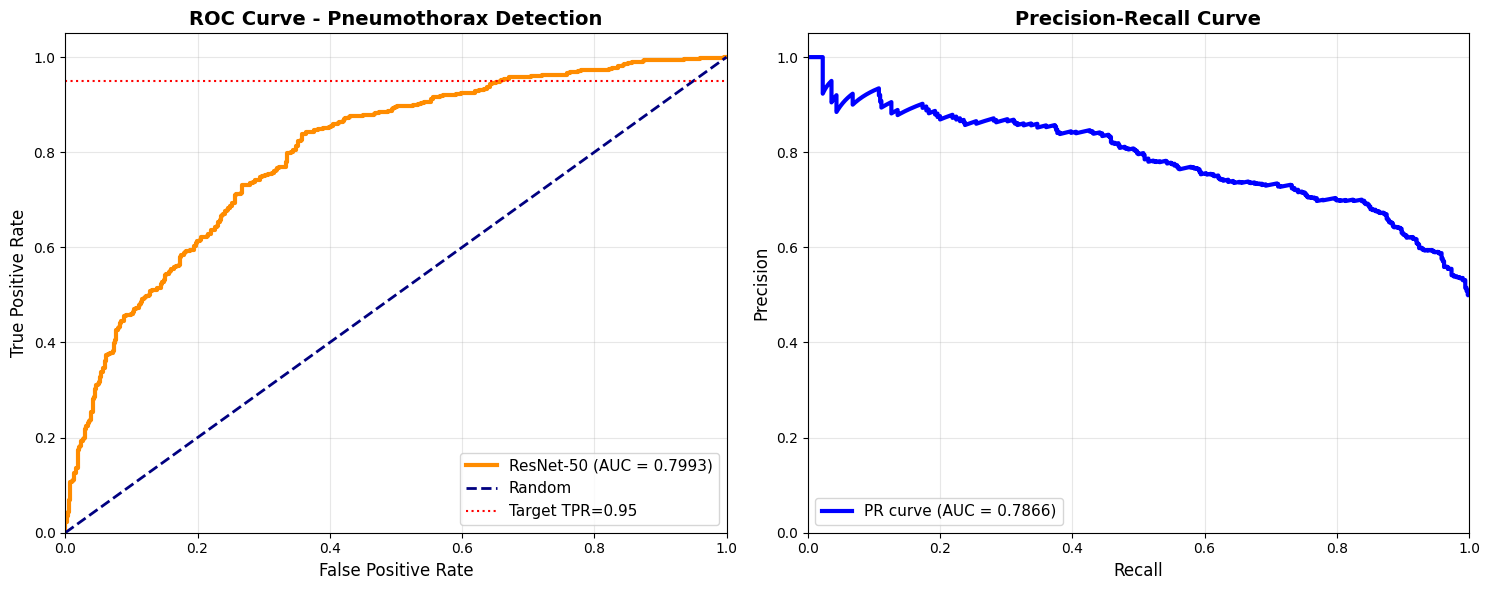


✓ ROC-AUC: 0.7993
✓ PR-AUC: 0.7866


In [11]:
# Cell 12: ROC and PR Curves
def plot_evaluation_curves(y_true, y_pred_prob, auc_score):
    """Plot ROC and Precision-Recall curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    
    ax1.plot(fpr, tpr, color='darkorange', lw=3, 
            label=f'ResNet-50 (AUC = {auc_score:.4f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax1.axhline(y=0.95, color='red', linestyle=':', label='Target TPR=0.95')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curve - Pneumothorax Detection', fontsize=14, fontweight='bold')
    ax1.legend(loc="lower right", fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_prob)
    pr_auc = auc(recall, precision)
    
    ax2.plot(recall, precision, color='blue', lw=3,
            label=f'PR curve (AUC = {pr_auc:.4f})')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontsize=12)
    ax2.set_ylabel('Precision', fontsize=12)
    ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax2.legend(loc="lower left", fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('./output/baseline_resnet50_evaluation_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ ROC-AUC: {auc_score:.4f}")
    print(f"✓ PR-AUC: {pr_auc:.4f}")

if 'y_true' in locals() and 'y_pred_prob' in locals():
    plot_evaluation_curves(y_true, y_pred_prob, auc_score)

In [12]:
# Cell 13: Save Results Summary
if 'auc_score' in locals():
    results = {
        'model': 'Baseline ResNet-50',
        'task': 'Binary Pneumothorax Detection',
        'target_auc': 0.95,
        'achieved_auc': float(auc_score),
        'test_samples': len(y_true),
        'positive_samples': int(y_true.sum()),
        'negative_samples': int(len(y_true) - y_true.sum()),
        'confusion_matrix': cm.tolist(),
        'target_achieved': bool(auc_score >= 0.95),
        'training_epochs': len(history.history['loss']),
        'best_val_auc': float(max(history.history['val_auc'])),
        'best_epoch': int(np.argmax(history.history['val_auc'])) + 1
    }
    
    import json
    with open('./output/baseline_resnet50_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n✓ Results saved to: ./output/baseline_resnet50_results.json")
    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)
    print(f"Model: Baseline ResNet-50")
    print(f"Test AUC: {auc_score:.4f}")
    print(f"Target: ≥ 0.95")
    print(f"Status: {'✓ ACHIEVED' if auc_score >= 0.95 else '⚠ NOT REACHED'}")
    print("=" * 60)


✓ Results saved to: ./output/baseline_resnet50_results.json

TRAINING COMPLETE
Model: Baseline ResNet-50
Test AUC: 0.7993
Target: ≥ 0.95
Status: ⚠ NOT REACHED
